**bold text** here is the
## Githud repsitory link
https://github.com/imparwasha/AI-Assignments

In [1]:
# important libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# load dataset

data = pd.read_csv("Pakistan Largest Ecommerce Dataset.csv")
data.head()

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,Month,Customer Since,M-Y,FY,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,211131,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,100147443.0,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,1.0,NaN,NaN,NaN,NaN,NaN
1,211133,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444.0,Beauty & Grooming,\N,...,7.0,2016-7,7-2016,FY17,2.0,NaN,NaN,NaN,NaN,NaN
2,211134,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445.0,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,3.0,NaN,NaN,NaN,NaN,NaN
3,211135,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147446.0,Beauty & Grooming,R-FSD-52352,...,7.0,2016-7,7-2016,FY17,4.0,NaN,NaN,NaN,NaN,NaN
4,211136,order_refunded,7/1/2016,BK7010400AG,555.0,2.0,1110.0,100147447.0,Soghaat,\N,...,7.0,2016-7,7-2016,FY17,5.0,NaN,NaN,NaN,NaN,NaN


In [4]:
# Remove unused columns

data.drop(['Customer ID'], axis=1, inplace=True, errors='Ignore')

In [5]:
# check null values.

data.isnull().sum()

,0
item_id,0
status,0
created_at,0
sku,2
price,1
qty_ordered,1
grand_total,1
increment_id,1
category_name_1,1
sales_commission_code,1


In [6]:
# fill with mean

data.fillna(data.mean(numeric_only=True), inplace=True)

In [7]:
# handle duplicates

data.drop_duplicates(inplace=True)

In [8]:
# handle categorical features

data = pd.get_dummies(data, drop_first=True, sparse=True)

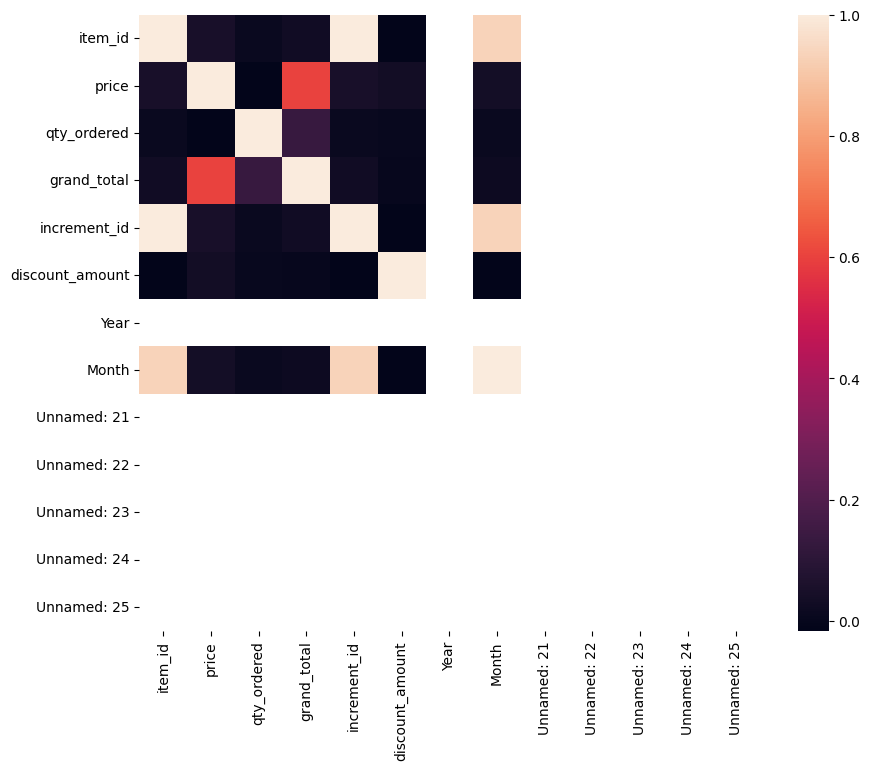

In [9]:
# correlation

corr = data.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr)
plt.show()

In [10]:
data = pd.read_csv("Pakistan Largest Ecommerce Dataset.csv")

/tmp/ipykernel_211/2051359929.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("Pakistan Largest Ecommerce Dataset.csv")


In [11]:
# correlation with target variable
data['grand_total'] = pd.to_numeric(data['grand_total'], errors='coerce')
numeric_cols = data.select_dtypes(include=[np.number]).columns
data[numeric_cols].corr()['grand_total'].sort_values(ascending=False)

,grand_total
grand_total,1.000000
qty_ordered,0.901374
price,0.167606
discount_amount,0.055145
Year,0.016452
item_id,0.012590
Customer ID,0.012439
Month,-0.010827
Unnamed: 21,NaN
Unnamed: 22,NaN


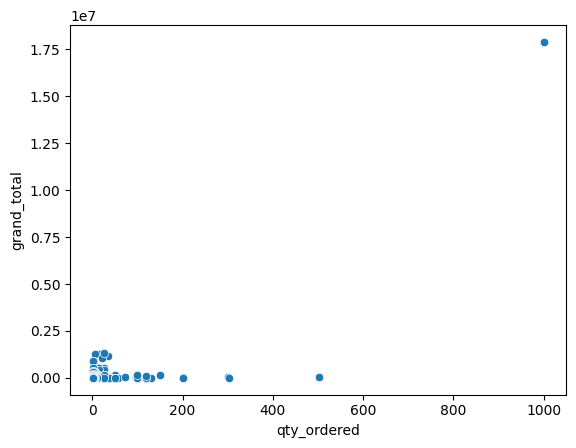

In [12]:
#scatter plot

sns.scatterplot(x='qty_ordered', y='grand_total', data=data)
plt.show()

In [13]:
# handle outliers

Q1 = data['grand_total'].quantile(0.25)
Q3 = data['grand_total'].quantile(0.75)
IQR = Q3 - Q1
data = data[(data['grand_total'] >= Q1 - 1.5 * IQR) & (data['grand_total'] <= Q3 + 1.5 * IQR)]



In [14]:
# data analytics
# best selling category

data['category_name_1'].value_counts()

,count
category_name_1,
Men's Fashion,61480
Mobiles & Tablets,38352
Women's Fashion,34568
Superstore,31529
Soghaat,28176
Beauty & Grooming,26682
Appliances,19087
Home & Living,14803
Kids & Baby,10907


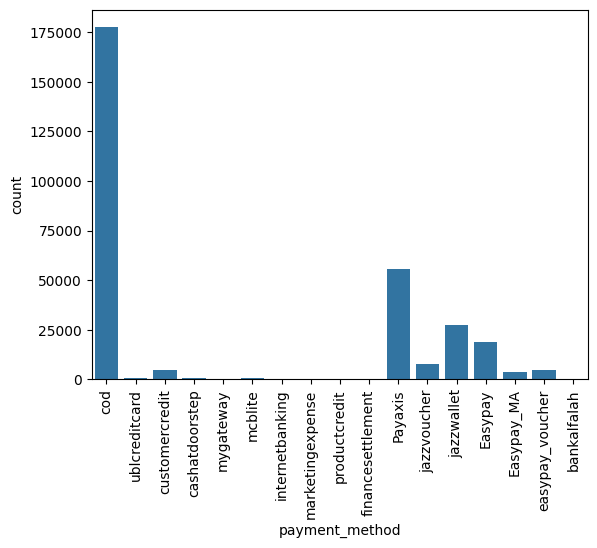

In [15]:
# payment method frequency

sns.countplot(x='payment_method', data=data)
plt.xticks(rotation=90)
plt.show()

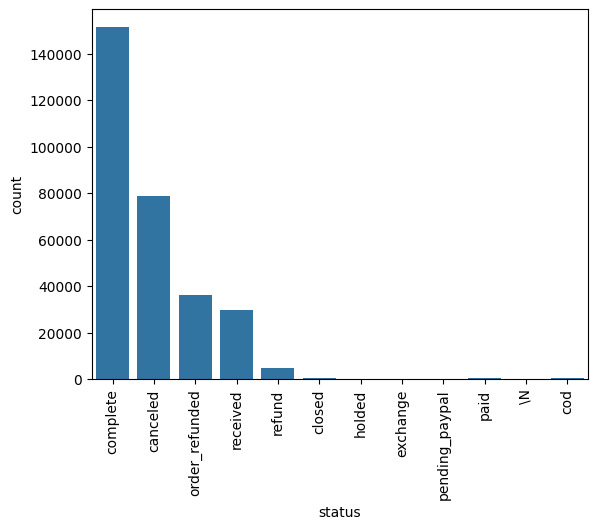

In [16]:
# order status frequency

sns.countplot(x='status', data=data)
plt.xticks(rotation=90)
plt.show()

In [17]:
# correlation payment method & order status

pd.crosstab(data['payment_method'], data['status'])

status,\N,canceled,closed,cod,complete,exchange,holded,order_refunded,paid,pending_paypal,received,refund
payment_method,,,,,,,,,,,,
Easypay,0,12060,3,0,4667,0,0,636,76,0,958,202
Easypay_MA,0,2139,0,0,1125,0,0,124,11,0,280,31
Payaxis,0,34400,26,0,13843,0,0,2176,242,0,4606,295
bankalfalah,0,3,0,0,0,0,0,1,0,0,0,1
cashatdoorstep,0,4,0,0,638,0,0,28,0,0,4,17
cod,4,10414,241,630,110067,4,6,31324,0,7,21110,3633
customercredit,0,39,24,0,3100,0,0,772,18,0,497,152
easypay_voucher,0,2309,0,0,2086,0,0,128,0,0,105,70
financesettlement,0,0,0,0,1,0,0,1,0,0,0,0


In [18]:
# correlation payment method & order status

pd.crosstab(data['payment_method'], data['status'])

status,\N,canceled,closed,cod,complete,exchange,holded,order_refunded,paid,pending_paypal,received,refund
payment_method,,,,,,,,,,,,
Easypay,0,12060,3,0,4667,0,0,636,76,0,958,202
Easypay_MA,0,2139,0,0,1125,0,0,124,11,0,280,31
Payaxis,0,34400,26,0,13843,0,0,2176,242,0,4606,295
bankalfalah,0,3,0,0,0,0,0,1,0,0,0,1
cashatdoorstep,0,4,0,0,638,0,0,28,0,0,4,17
cod,4,10414,241,630,110067,4,6,31324,0,7,21110,3633
customercredit,0,39,24,0,3100,0,0,772,18,0,497,152
easypay_voucher,0,2309,0,0,2086,0,0,128,0,0,105,70
financesettlement,0,0,0,0,1,0,0,1,0,0,0,0


In [19]:
# correlation payment method & order status

pd.crosstab(data['payment_method'], data['status'])

status,\N,canceled,closed,cod,complete,exchange,holded,order_refunded,paid,pending_paypal,received,refund
payment_method,,,,,,,,,,,,
Easypay,0,12060,3,0,4667,0,0,636,76,0,958,202
Easypay_MA,0,2139,0,0,1125,0,0,124,11,0,280,31
Payaxis,0,34400,26,0,13843,0,0,2176,242,0,4606,295
bankalfalah,0,3,0,0,0,0,0,1,0,0,0,1
cashatdoorstep,0,4,0,0,638,0,0,28,0,0,4,17
cod,4,10414,241,630,110067,4,6,31324,0,7,21110,3633
customercredit,0,39,24,0,3100,0,0,772,18,0,497,152
easypay_voucher,0,2309,0,0,2086,0,0,128,0,0,105,70
financesettlement,0,0,0,0,1,0,0,1,0,0,0,0


A pattren which is hidden is observed in the dataset is that a large number of customers prefer cash on delivery as their payment method, additionaly some categories generate higher revenue even with fewer orders because their products have higher prices

In [20]:
# save preprocessed dataset

data.to_csv('preprocessed_ecommerce_data.csv', index=False)